<a href="https://colab.research.google.com/github/usman-infinity/Final_For_The_Research_Paper-/blob/main/Copy_of_MODEL%3ECNN_BiGRU_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pakistan_air_quality_final_clean.csv to pakistan_air_quality_final_clean.csv
Dataset Columns: Index(['timestamp', 'city', 'latitude', 'longitude', 'pm10', 'pm2_5',
       'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'dust', 'temperature', 'humidity', 'precipitation', 'wind_speed',
       'wind_direction', 'pressure', 'date', 'hour', 'day_of_week', 'month',
       'month_name', 'year', 'is_weekend', 'season', 'aqi_category'],
      dtype='object')
Dataset shape after cleaning: (21840, 4)
X shape: (21815, 24, 2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 12, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,066 (406.51 KB)

 Trainable params: 104,066 (406.51 KB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 178s 10ms/step - loss: 0.0023 - mae: 0.0309 - val_loss: 0.0013 - val_mae: 0.0230
Epoch 2/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 171s 10ms/step - loss: 0.0011 - mae: 0.0224 - val_loss: 3.8294e-04 - val_mae: 0.0127
Epoch 3/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 171s 10ms/step - loss: 9.4265e-04 - mae: 0.0207 - val_loss: 8.4413e-04 - val_mae: 0.0190
Epoch 4/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 171s 10ms/step - loss: 8.9722e-04 - mae: 0.0201 - val_loss: 5.1579e-04 - val_mae: 0.0179
Epoch 5/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 174s 10ms/step - loss: 8.1112e-04 - mae: 0.0192 - val_loss: 3.9828e-04 - val_mae: 0.0145
Epoch 6/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 171s 10ms/step - loss: 8.0282e-04 - mae: 0.0189 - val_loss: 9.7326e-04 - val_mae: 0.0262
Epoch 7/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 166s 10ms/step - loss: 7.7329e-04 - mae: 0.0187 - val_loss: 4.4371e-04 - val_mae: 0.0141
Epoch 8/20
17452/17452 ━━━━━━━━━━━━━━━━━━━━ 168s 10ms/step 

,Pollutant,MAE,RMSE,R2
0,PM10,6.5967,9.4957,0.9706
1,PM25,6.9795,9.8239,0.9681



--- City-wise Model Evaluation Metrics ---


,City,Pollutant,MAE,RMSE
0,Rawalpindi,PM10,4.7315,6.6322
1,Rawalpindi,PM25,4.8669,6.5670
2,Sialkot,PM10,8.4594,11.6742
3,Sialkot,PM25,9.0891,12.2400


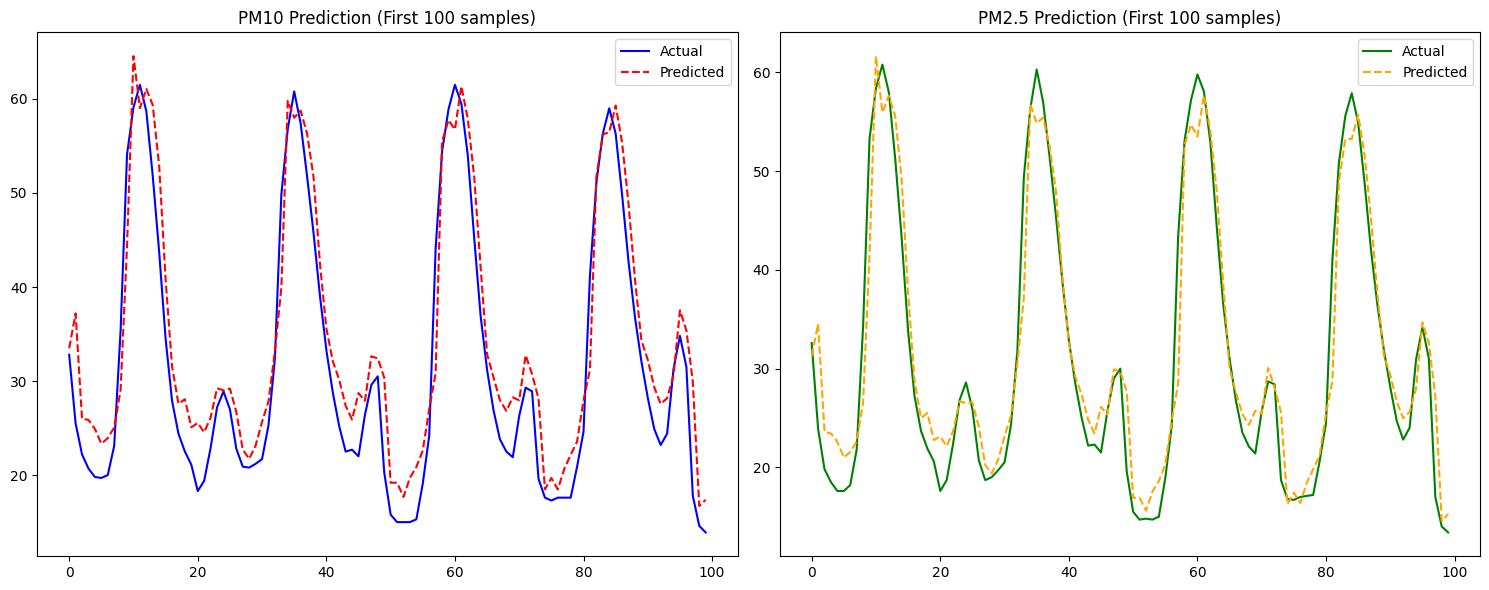

Model saved as 'cnn_bigru_lstm_model.h5'


In [ ]:
# =========================================================
# 🚀 GOOGLE COLAB FULL CODE: CNN + BiGRU + LSTM
# =========================================================

# ----------------------------
# 0️⃣ Install & Setup
# ----------------------------
!pip install -q tensorflow scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------
# 1️⃣ Upload Dataset
# ----------------------------
from google.colab import files
uploaded = files.upload()

# Load dataset
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Dataset Columns:", df.columns)

# ----------------------------
# 2️⃣ Data Preprocessing
# ----------------------------
# Normalize column names
df.rename(columns={'pm2_5':'pm25', 'PM2.5':'pm25', 'PM10':'pm10'}, inplace=True)
# Keep city column to enable city-wise evaluation later
df = df[['timestamp','city','pm10','pm25']]

df['timestamp'] = pd.to_datetime(df['timestamp'])
# Do NOT set timestamp as index here, as it might not be unique (e.g., multiple cities at same timestamp)

# Handle missing values
df = df.dropna()
print("Dataset shape after cleaning:", df.shape)

# Store city information BEFORE dropping columns for scaling
cities_info = df['city'].values

# Create a numeric-only DataFrame for scaling and model input
# Drop timestamp as well, as create_dataset will work on the numeric values directly
df_numeric = df.drop(columns=['city', 'timestamp'])

# ----------------------------
# 3️⃣ Normalize Data
# ----------------------------
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_numeric)

# ----------------------------
# 4️⃣ Create Time-Series Dataset
# ----------------------------
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), :])
        y.append(data[i+time_step, :])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(scaled_data, time_step)
print("X shape:", X.shape) # Expected: (samples, 24, 2)

# Get cities for 'y' samples by slicing the `cities_info` array.
# y[0] corresponds to the row at index `time_step` in the `scaled_data` array,
# which corresponds to the row at index `time_step` in the original `df`.
cities_for_y = cities_info[time_step : time_step + len(y)]

# ----------------------------
# 5️⃣ Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test, cities_for_y_train, cities_for_y_test = train_test_split(
    X, y, cities_for_y, test_size=0.2, shuffle=False
)

# ----------------------------
# 6️⃣ Positional Encoding (Optional but kept for Hybrid Structure)
# ----------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(seq_len, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
        return pos * angles

    def positional_encoding(self, seq_len, d_model):
        angle_rads = self.get_angles(
            np.arange(seq_len)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model
        )
        angle_rads[:,0::2] = np.sin(angle_rads[:,0::2])
        angle_rads[:,1::2] = np.cos(angle_rads[:,1::2])
        return tf.cast(angle_rads[np.newaxis,...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

# ----------------------------
# 7️⃣ Build Model (CNN + BiGRU + LSTM)
# ----------------------------
d_model = 64

inputs = layers.Input(shape=(time_step, 2))

# A. CNN for Spatial/Local Feature Extraction
x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(pool_size=2)(x)

# B. Match Dimensions for Recurrent Layers
x = layers.Dense(d_model)(x)
x = PositionalEncoding(time_step // 2, d_model)(x)

# C. BiGRU for Bidirectional Temporal Context
x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)

# D. LSTM for Long-term Dependency Capture
x = layers.LSTM(64, return_sequences=False)(x)

# E. Output Head
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(2)(x) # Predicting both PM10 and PM25

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# ----------------------------
# 8️⃣ Train Model
# ----------------------------
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 9️⃣ Prediction & Evaluation
# ----------------------------
predictions = model.predict(X_test)

# Inverse scaling
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# Calculate Metrics for PM10
mae_pm10 = mean_absolute_error(y_test_inv[:, 0], predictions_inv[:, 0])
rmse_pm10 = np.sqrt(mean_squared_error(y_test_inv[:, 0], predictions_inv[:, 0]))
r2_pm10 = r2_score(y_test_inv[:, 0], predictions_inv[:, 0])

# Calculate Metrics for PM2.5
mae_pm25 = mean_absolute_error(y_test_inv[:, 1], predictions_inv[:, 1])
rmse_pm25 = np.sqrt(mean_squared_error(y_test_inv[:, 1], predictions_inv[:, 1]))
r2_pm25 = r2_score(y_test_inv[:, 1], predictions_inv[:, 1])

# Create a DataFrame for structured output
metrics_data = {
    'Pollutant': ['PM10', 'PM25'],
    'MAE': [mae_pm10, mae_pm25],
    'RMSE': [rmse_pm10, rmse_pm25],
    'R2': [r2_pm10, r2_pm25]
}
metrics_df = pd.DataFrame(metrics_data)

print("\nModel Evaluation Metrics (Overall):")
display(metrics_df.round(4))

# ----------------------------
# 9️⃣.1 City-wise Model Evaluation
# ----------------------------
print("\n--- City-wise Model Evaluation Metrics ---")

unique_cities = np.unique(cities_for_y_test)
city_metrics_list = []

for city in unique_cities:
    # Filter predictions and actuals for the current city
    city_mask = (cities_for_y_test == city)
    city_y_test_inv = y_test_inv[city_mask]
    city_predictions_inv = predictions_inv[city_mask]

    if len(city_y_test_inv) == 0:
        print(f"No test data available for city: {city}")
        continue

    # Calculate Metrics for PM10 for the current city
    mae_pm10_city = mean_absolute_error(city_y_test_inv[:, 0], city_predictions_inv[:, 0])
    rmse_pm10_city = np.sqrt(mean_squared_error(city_y_test_inv[:, 0], city_predictions_inv[:, 0]))

    # Calculate Metrics for PM2.5 for the current city
    mae_pm25_city = mean_absolute_error(city_y_test_inv[:, 1], city_predictions_inv[:, 1])
    rmse_pm25_city = np.sqrt(mean_squared_error(city_y_test_inv[:, 1], city_predictions_inv[:, 1]))

    city_metrics_list.append({
        'City': city,
        'Pollutant': 'PM10',
        'MAE': mae_pm10_city,
        'RMSE': rmse_pm10_city
    })
    city_metrics_list.append({
        'City': city,
        'Pollutant': 'PM25',
        'MAE': mae_pm25_city,
        'RMSE': rmse_pm25_city
    })

city_metrics_df = pd.DataFrame(city_metrics_list)
display(city_metrics_df.round(4))

# ----------------------------
# 🔟 Visualization
# ----------------------------
plt.figure(figsize=(15, 6))

# PM10 Plot
plt.subplot(1, 2, 1)
plt.plot(y_test_inv[:100, 0], label='Actual', color='blue')
plt.plot(predictions_inv[:100, 0], label='Predicted', color='red', linestyle='--')
plt.title("PM10 Prediction (First 100 samples)")
plt.legend()

# PM2.5 Plot
plt.subplot(1, 2, 2)
plt.plot(y_test_inv[:100, 1], label='Actual', color='green')
plt.plot(predictions_inv[:100, 1], label='Predicted', color='orange', linestyle='--')
plt.title("PM2.5 Prediction (First 100 samples)")
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# 1️⃣1️⃣ Save Model
# ----------------------------
model.save('cnn_bigru_lstm_model.h5')
print("Model saved as 'cnn_bigru_lstm_model.h5'")


In [ ]:
# --- 3. Evaluate Each City ---
city_results = [] # Initialize the list
for city in df['city'].unique():
    city_df = df[df['city'] == city][['pm10', 'pm25']].dropna()

    if len(city_df) < 50: continue # Skip if data is too small

    # Scale data
    scaled_data = scaler.fit_transform(city_df)

    # Create windows for prediction
    X_city, y_city = create_dataset(scaled_data) # Changed create_windows to create_dataset

    # Generate PREDICTIONS
    preds_scaled = model.predict(X_city, verbose=0)

    # Inverse scaling to get real ug/m3 values
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(y_city)

    for i, pollutant in enumerate(['PM10', 'PM25']):
        mae = mean_absolute_error(actual[:, i], preds[:, i])
        rmse = np.sqrt(mean_squared_error(actual[:, i], preds[:, i]))
        r2 = r2_score(actual[:, i], preds[:, i])

        city_results.append({
            'City': city,
            'Pollutant': pollutant,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 4)
        })

In [ ]:
city_metrics_df_individual = pd.DataFrame(city_results)
display(city_metrics_df_individual)

,City,Pollutant,MAE,RMSE,R2
0,Faisalabad,PM10,10.99,16.27,0.9615
1,Faisalabad,PM25,11.65,16.88,0.9583
2,Islamabad,PM10,5.62,7.69,0.9289
3,Islamabad,PM25,5.83,7.84,0.9224
4,Karachi,PM10,21.85,26.07,-0.5153
5,Karachi,PM25,8.87,10.76,0.4855
6,Lahore,PM10,7.92,11.90,0.9640
7,Lahore,PM25,8.79,12.90,0.9576
8,Multan,PM10,8.85,13.98,0.9626
9,Multan,PM25,10.41,15.13,0.9557
